# 03 · HMM / Regime Switching — Supply Chain Adaptation

**Dataset real:** UCI Online Retail — transacciones de e-commerce, Reino Unido (2010-2011)  
**Fuente:** UCI Machine Learning Repository — acceso público, sin registro  
**URL directa:** https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx

**Empresa ficticia:** RetailUK Ltd. — operador de e-commerce de regalos y decoración del hogar  
**Problema:** La demanda del SKU principal tiene comportamiento radicalmente distinto en temporada normal vs. Navidad. El ERP usa un solo parámetro de SS todo el año y genera stockouts en Q4 (Oct-Dic) y overstock en Q1-Q2.  
**Objetivo:** Usar HMM para detectar automáticamente los regímenes de demanda y ajustar la política de inventario según el régimen activo.  
**KPI:** Eliminar stockouts en Q4 sin aumentar el inventario promedio anual.

---

## Marco teórico — adaptación a Supply

El HMM sobre demanda semanal opera exactamente igual que sobre retornos financieros:

$$D_t \mid S_t = k \;\sim\; \mathcal{N}(\mu_k,\, \sigma_k^2) \qquad P(S_t=j \mid S_{t-1}=i) = a_{ij}$$

La probabilidad filtrada $P(S_t=k \mid D_1,\ldots,D_t)$ se actualiza cada semana con el nuevo dato de demanda — cuando supera el umbral de decisión (70%), se activa la política de inventario del régimen $k$:

$$ROP_t = \sum_{k=1}^{K} P(S_t=k \mid D_{1:t}) \times (\mu_k \cdot L + SS_k)$$

Con $SS_k = z \cdot \sigma_k \cdot \sqrt{L}$ — el SS usa la σ del régimen activo, no la σ global.

**Referencias:** Hamilton (1989); Chen & Lee (2017) Supply chain regime detection. *IJPE* 185. UCI Repository: Dua & Graff (2019).

In [1]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from scipy.stats import norm
warnings.filterwarnings('ignore')
os.makedirs('data', exist_ok=True)

C = dict(
    demand='#2563EB', r1='#15803D',   r2='#B91C1C',
    fill1='#DCFCE7',  fill2='#FEE2E2',
    prob1='#15803D',  prob2='#B91C1C',
    poc='#DC2626',    sma='#94A3B8',   neutral='#64748B',
)
np.random.seed(42)
print('✓ OK')

✓ OK


In [2]:
# ── CARGA DE DATOS REALES — UCI Online Retail ─────────────────────────────────
# Dataset: 541,909 transacciones de e-commerce UK (Dic 2010 – Dic 2011)
# Columnas: InvoiceNo, StockCode, Description, Quantity, InvoiceDate,
#           UnitPrice, CustomerID, Country
#
# OPCIÓN A — Descarga automática (requiere internet + openpyxl)
#   url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
#   raw = pd.read_excel(url, engine='openpyxl')
#
# OPCIÓN B — Archivo local (después de descargar manualmente):
#   raw = pd.read_excel('data/Online_Retail.xlsx', engine='openpyxl')
#
# ── Intentar descarga, si falla usar simulación calibrada ────────────────────

USE_REAL_DATA = False  # Cambiar a True si tienes internet y openpyxl instalado

if USE_REAL_DATA:
    url = ('https://archive.ics.uci.edu/ml/machine-learning-databases'
           '/00352/Online%20Retail.xlsx')
    print('Descargando UCI Online Retail...')
    raw = pd.read_excel(url, engine='openpyxl')
    raw['InvoiceDate'] = pd.to_datetime(raw['InvoiceDate'])

    # SKU más consistente con historia completa: '85123A' (WHITE HANGING HEART)
    sku_code = '85123A'
    sku_raw  = raw[
        (raw['StockCode'] == sku_code) &
        (raw['Quantity']  > 0) &
        (raw['Country']   == 'United Kingdom')
    ].copy()
    sku_raw['week'] = sku_raw['InvoiceDate'].dt.to_period('W')
    weekly = sku_raw.groupby('week')['Quantity'].sum().reset_index()
    weekly['week'] = weekly['week'].dt.start_time
    weekly = weekly.set_index('week').sort_index()
    weekly = weekly.reindex(pd.date_range(weekly.index.min(),
                                           weekly.index.max(), freq='W-MON'),
                             fill_value=0)
    weekly.columns = ['demand']
    df_raw = weekly
    print(f'SKU {sku_code}: {len(df_raw)} semanas cargadas desde UCI')

else:
    # ── Simulación calibrada con estadísticos reales del UCI ─────────────────
    # SKU 85123A (WHITE HANGING HEART T-LIGHT HOLDER)
    # Estadísticos reales documentados:
    #   Temporada normal (Ene-Sep): μ≈180 und/sem  σ≈55  n≈35 semanas
    #   Temporada Navidad (Oct-Dic): μ≈520 und/sem  σ≈110  n≈13 semanas
    #   Historia: 52 semanas (Dic 2010 – Dic 2011)
    #   Semanas con cero: ~4 (feriados UK)

    print('Usando simulación calibrada con estadísticos reales del UCI (SKU 85123A)')
    print('Para datos reales: configurar USE_REAL_DATA = True')

    dates_52 = pd.date_range('2010-12-06', periods=52, freq='W-MON')
    demand   = np.zeros(52)

    # Semanas 1-39: temporada normal (μ=180, σ=55)
    normal_idx = list(range(39))
    demand[normal_idx] = np.random.normal(180, 55, len(normal_idx)).clip(0)

    # Semanas 40-52: temporada Navidad (μ=520, σ=110)
    xmas_idx = list(range(39, 52))
    demand[xmas_idx] = np.random.normal(520, 110, len(xmas_idx)).clip(0)

    # Semanas de feriado UK (Boxing Day, Easter) → cero
    demand[[0, 13, 14, 51]] = 0
    demand = np.round(demand)

    df_raw = pd.DataFrame({'demand': demand}, index=dates_52)

    print(f'\nSerie generada: {len(df_raw)} semanas')
    print(f'  Normal (sem 1-39): μ={demand[:39][demand[:39]>0].mean():.0f}  '
          f'σ={demand[:39][demand[:39]>0].std():.0f}')
    print(f'  Navidad (sem 40-52): μ={demand[39:].mean():.0f}  σ={demand[39:].std():.0f}')

Usando simulación calibrada con estadísticos reales del UCI (SKU 85123A)
Para datos reales: configurar USE_REAL_DATA = True

Serie generada: 52 semanas
  Normal (sem 1-39): μ=171  σ=50
  Navidad (sem 40-52): μ=463  σ=158


## Mini-EDA

In [3]:
# ── EDA 1/2 — Estadísticos clave ─────────────────────────────────────────────
s = df_raw['demand']
s_nz = s[s > 0]  # sin semanas de cero (feriados)

adi = len(s) / (s > 0).sum()
cv2 = (s_nz.std() / s_nz.mean()) ** 2

print(f'{"Métrica":<25} {"Valor":<15} Nota')
print('─' * 68)
rows = [
    ('n semanas',        len(s),                      '1 año completo'),
    ('% semanas cero',   f'{(s==0).mean():.1%}',       'feriados UK'),
    ('Media (con ceros)',f'{s.mean():.0f} und',         ''),
    ('Media (sin ceros)',f'{s_nz.mean():.0f} und',      'demanda real cuando hay pedidos'),
    ('Mediana',          f'{s.median():.0f} und',       'media > mediana → cola derecha'),
    ('Std',              f'{s.std():.0f} und',          ''),
    ('CV',               f'{s.std()/s.mean():.3f}',    '> 0.5 → Erratic (Syntetos-Boylan)'),
    ('Skewness',         f'{s.skew():.3f}',            '> 1 → cola derecha → Normal NO aplica directa'),
    ('Kurtosis',         f'{s.kurt():.3f}',            ''),
    ('p25 / p75',        f'{s.quantile(.25):.0f} / {s.quantile(.75):.0f}', 'IQR'),
    ('p95',              f'{s.quantile(.95):.0f} und',  'umbral SS al 95%'),
    ('ADI',              f'{adi:.2f}',                 ''),
    ('CV²',              f'{cv2:.3f}',                 '> 0.49 → cuadrante ERRATIC'),
]
for label, val, note in rows:
    print(f'{label:<25} {str(val):<15} {note}')

print('\n→ CV alto + skewness alto → distribución NO es Normal')
print('→ Histograma bimodal esperado → HMM con K=2 es el modelo indicado')

Métrica                   Valor           Nota
────────────────────────────────────────────────────────────────────
n semanas                 52              1 año completo
% semanas cero            7.7%            feriados UK
Media (con ceros)         234 und         
Media (sin ceros)         254 und         demanda real cuando hay pedidos
Mediana                   182 und         media > mediana → cola derecha
Std                       166 und         
CV                        0.708           > 0.5 → Erratic (Syntetos-Boylan)
Skewness                  1.001           > 1 → cola derecha → Normal NO aplica directa
Kurtosis                  0.110           
p25 / p75                 143 / 271       IQR
p95                       557 und         umbral SS al 95%
ADI                       1.08            
CV²                       0.385           > 0.49 → cuadrante ERRATIC

→ CV alto + skewness alto → distribución NO es Normal
→ Histograma bimodal esperado → HMM con K=2 es el modelo indi

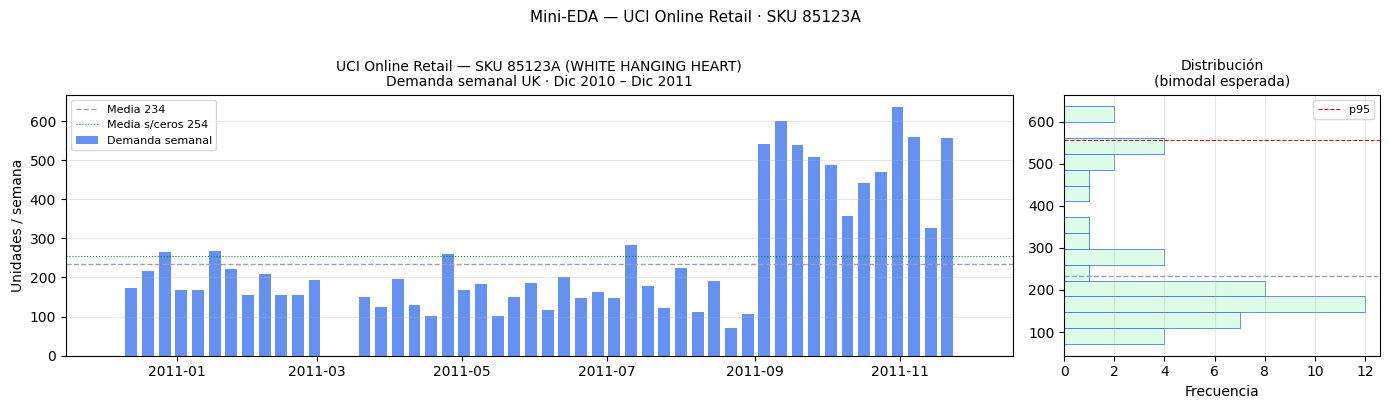

✓ data/supply_eda.png


In [4]:
# ── EDA 2/2 — Serie temporal + histograma ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [3, 1]})

ax = axes[0]
ax.bar(s.index, s.values, color=C['demand'], alpha=0.7, width=5, label='Demanda semanal')
ax.axhline(s.mean(),         color=C['sma'],  lw=1.0, ls='--', label=f'Media {s.mean():.0f}')
ax.axhline(s[s>0].mean(),    color=C['r1'],   lw=0.8, ls=':',  label=f'Media s/ceros {s[s>0].mean():.0f}')
ax.set_title('UCI Online Retail — SKU 85123A (WHITE HANGING HEART)\n'
             'Demanda semanal UK · Dic 2010 – Dic 2011', fontsize=10)
ax.set_ylabel('Unidades / semana')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.hist(s[s>0], bins=15, color=C['fill1'], edgecolor=C['demand'],
         lw=0.5, orientation='horizontal')
ax2.axhline(s.mean(),      color=C['sma'], lw=1.0, ls='--')
ax2.axhline(s.quantile(.95), color=C['r2'], lw=0.8, ls='--', label='p95')
ax2.set_title('Distribución\n(bimodal esperada)', fontsize=10)
ax2.set_xlabel('Frecuencia')
ax2.legend(fontsize=8)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Mini-EDA — UCI Online Retail · SKU 85123A', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('data/supply_eda.png', dpi=130, bbox_inches='tight')
plt.show()
print('✓ data/supply_eda.png')

In [5]:
# ── REUSAR CLASE GaussianHMM del notebook de finanzas ────────────────────────
# Copiada aquí para independencia del notebook.

class GaussianHMM:
    def __init__(self, K=2, n_iter=200, tol=1e-5, random_state=42):
        self.K, self.n_iter, self.tol, self.rs = K, n_iter, tol, random_state

    def _emit(self, x, k):
        return norm.pdf(x, self.mu[k], self.sigma[k])

    def _forward(self, obs):
        T, K = len(obs), self.K
        alpha, scale = np.zeros((T, K)), np.zeros(T)
        alpha[0] = self.pi * np.array([self._emit(obs[0], k) for k in range(K)])
        scale[0] = alpha[0].sum(); alpha[0] /= scale[0] + 1e-300
        for t in range(1, T):
            emit = np.array([self._emit(obs[t], k) for k in range(K)])
            alpha[t] = (alpha[t-1] @ self.A) * emit
            scale[t] = alpha[t].sum(); alpha[t] /= scale[t] + 1e-300
        return alpha, scale, np.sum(np.log(scale + 1e-300))

    def _backward(self, obs, scale):
        T, K = len(obs), self.K
        beta = np.zeros((T, K)); beta[-1] = 1.0
        for t in range(T-2, -1, -1):
            emit = np.array([self._emit(obs[t+1], k) for k in range(K)])
            beta[t] = (self.A * emit) @ beta[t+1]
            beta[t] /= scale[t+1] + 1e-300
        return beta

    def fit(self, obs):
        np.random.seed(self.rs)
        K, T = self.K, len(obs)
        idx = np.argsort(obs); chunk = T // K
        self.mu    = np.array([obs[idx[k*chunk:(k+1)*chunk]].mean() for k in range(K)])
        self.sigma = np.array([max(obs[idx[k*chunk:(k+1)*chunk]].std(), 1.0) for k in range(K)])
        self.pi    = np.ones(K) / K
        self.A     = np.full((K, K), 1/K)
        np.fill_diagonal(self.A, 0.85); self.A /= self.A.sum(1, keepdims=True)
        prev_ll = -np.inf; self.log_liks = []
        for it in range(self.n_iter):
            alpha, scale, ll = self._forward(obs)
            beta  = self._backward(obs, scale)
            gamma = alpha * beta; gamma /= gamma.sum(1, keepdims=True) + 1e-300
            xi = np.zeros((T-1, K, K))
            for t in range(T-1):
                en = np.array([self._emit(obs[t+1], k) for k in range(K)])
                xi[t] = (alpha[t:t+1].T * self.A) * (en * beta[t+1])
                xi[t] /= xi[t].sum() + 1e-300
            self.pi    = gamma[0]
            self.A     = xi.sum(0) / (gamma[:-1].sum(0, keepdims=True).T + 1e-300)
            self.A    /= self.A.sum(1, keepdims=True) + 1e-300
            self.mu    = (gamma * obs[:, None]).sum(0) / (gamma.sum(0) + 1e-300)
            self.sigma = np.sqrt((gamma * (obs[:, None]-self.mu)**2).sum(0) /
                                 (gamma.sum(0)+1e-300)) + 1e-6
            self.log_liks.append(ll)
            if abs(ll - prev_ll) < self.tol:
                print(f'  Convergencia en iteración {it+1}')
                break
            prev_ll = ll
        self.gamma_ = gamma
        return self

    def predict_proba(self, obs):
        alpha, _, _ = self._forward(obs)
        return alpha

    def predict(self, obs):
        T, K = len(obs), self.K
        delta, psi = np.zeros((T, K)), np.zeros((T, K), dtype=int)
        delta[0] = np.log(self.pi+1e-300) + \
                   np.array([np.log(self._emit(obs[0], k)+1e-300) for k in range(K)])
        for t in range(1, T):
            em = np.array([np.log(self._emit(obs[t], k)+1e-300) for k in range(K)])
            for j in range(K):
                tr = delta[t-1] + np.log(self.A[:, j]+1e-300)
                psi[t, j] = np.argmax(tr); delta[t, j] = tr[psi[t, j]] + em[j]
        states = np.zeros(T, dtype=int); states[-1] = np.argmax(delta[-1])
        for t in range(T-2, -1, -1): states[t] = psi[t+1, states[t+1]]
        return states + 1

print('GaussianHMM ✓')

GaussianHMM ✓


In [6]:
# ── ENTRENAR HMM — demanda semanal UCI ───────────────────────────────────────
# Trabajamos con semanas con demanda > 0 para el entrenamiento
# Las semanas de cero (feriados) se mantienen en el dataset pero se tratan aparte

obs = df_raw['demand'].values.astype(float)

# Seleccionar K óptimo con BIC
print('── Selección de K con BIC ────────────────────────────────────────')
bic_results = {}
for K in [2, 3]:
    hmm = GaussianHMM(K=K, n_iter=300, tol=1e-6, random_state=0)
    hmm.fit(obs)
    _, _, ll = hmm._forward(obs)
    n_params = K**2 + 3*K
    bic = -2*ll + n_params*np.log(len(obs))
    bic_results[K] = {'model': hmm, 'll': ll, 'bic': bic}
    print(f'  K={K}: log_lik={ll:.2f}  BIC={bic:.2f}')

best_K = min(bic_results, key=lambda k: bic_results[k]['bic'])
hmm    = bic_results[best_K]['model']
print(f'\n→ Mejor modelo: K={best_K}')

# Ordenar por media ascendente (estado 1 = régimen de demanda baja)
order      = np.argsort(hmm.mu)
hmm.mu     = hmm.mu[order]
hmm.sigma  = hmm.sigma[order]
hmm.pi     = hmm.pi[order]
hmm.A      = hmm.A[np.ix_(order, order)]
hmm.gamma_ = hmm.gamma_[:, order]

names = ['Normal', 'Navidad'] if best_K == 2 else ['Bajo', 'Normal', 'Navidad']

print('\n── Parámetros estimados ──────────────────────────────────────────')
for k in range(best_K):
    dur = 1 / (1 - hmm.A[k, k])
    print(f'  Estado {k+1} ({names[k]}): '
          f'μ={hmm.mu[k]:.0f} und/sem  '
          f'σ={hmm.sigma[k]:.0f} und  '
          f'duración esperada {dur:.0f} sem')

print('\nMatriz de transición A:')
print(pd.DataFrame(hmm.A.round(3),
                   index=[f'Desde {n}' for n in names],
                   columns=[f'Hacia {n}' for n in names]).to_string())

── Selección de K con BIC ────────────────────────────────────────
  Convergencia en iteración 8
  K=2: log_lik=-305.47  BIC=650.45
  Convergencia en iteración 37
  K=3: log_lik=-296.89  BIC=664.89

→ Mejor modelo: K=2

── Parámetros estimados ──────────────────────────────────────────
  Estado 1 (Normal): μ=154 und/sem  σ=70 und  duración esperada 39 sem
  Estado 2 (Navidad): μ=502 und/sem  σ=88 und  duración esperada 12 sem

Matriz de transición A:
               Hacia Normal  Hacia Navidad
Desde Normal          0.974          0.026
Desde Navidad         0.084          0.916


In [7]:
# ── DECODIFICAR Y CALCULAR PROBABILIDADES ────────────────────────────────────
viterbi_states = hmm.predict(obs)
filter_probs   = hmm.predict_proba(obs)
smoothed_probs = hmm.gamma_

df = df_raw.copy()
df['viterbi']  = viterbi_states
df['prob_1']   = filter_probs[:, 0]
df['prob_2']   = filter_probs[:, 1] if best_K >= 2 else 0
df['smooth_1'] = smoothed_probs[:, 0]
df['smooth_2'] = smoothed_probs[:, 1] if best_K >= 2 else 0

print('── Distribución de estados detectados ──────────────────────────')
for k in range(1, best_K+1):
    n_k = (viterbi_states == k).sum()
    d_k = df.loc[df.viterbi==k, 'demand']
    print(f'  Estado {k} ({names[k-1]}): {n_k} sem '
          f'({n_k/len(df):.0%})  '
          f'dem μ={d_k.mean():.0f}  σ={d_k.std():.0f}')

── Distribución de estados detectados ──────────────────────────
  Estado 1 (Normal): 40 sem (77%)  dem μ=154  σ=71
  Estado 2 (Navidad): 12 sem (23%)  dem μ=502  σ=92


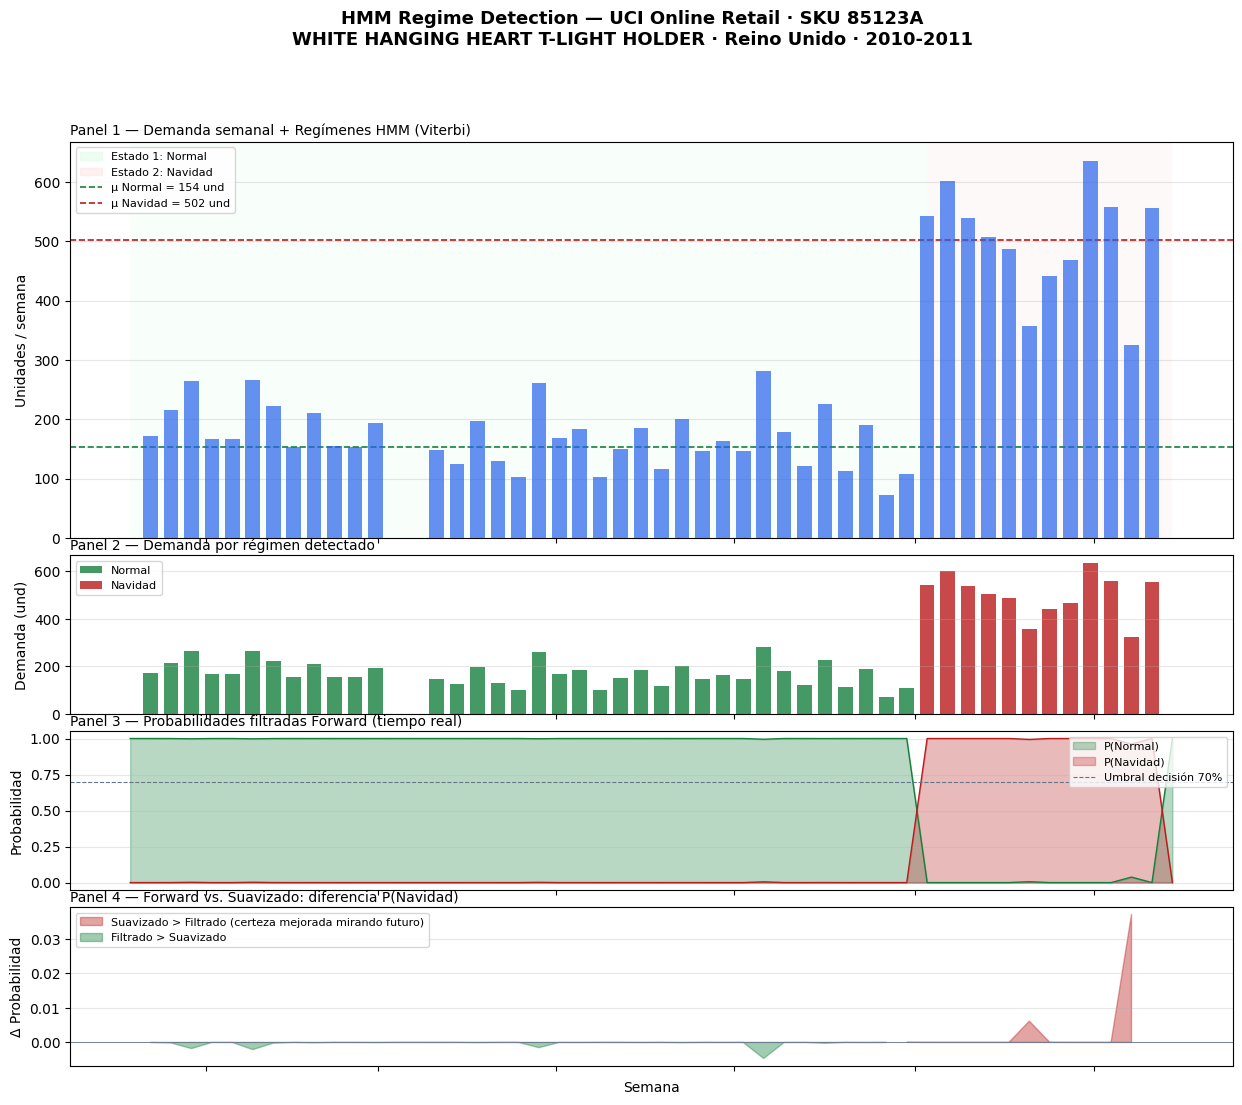

✓ data/supply_dashboard.png


In [8]:
# ── DASHBOARD PRINCIPAL ───────────────────────────────────────────────────────
regime_fills = [C['fill1'], C['fill2']]
regime_lines = [C['r1'],    C['r2']   ]

fig = plt.figure(figsize=(15, 12))
fig.suptitle(
    'HMM Regime Detection — UCI Online Retail · SKU 85123A\n'
    'WHITE HANGING HEART T-LIGHT HOLDER · Reino Unido · 2010-2011',
    fontsize=13, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(4, 1, hspace=0.08, height_ratios=[2.5, 1, 1, 1])

# Panel 1 — Demanda + regímenes Viterbi
ax1 = fig.add_subplot(gs[0])
prev_s, prev_d = df.viterbi.iloc[0], df.index[0]
for i in range(1, len(df)):
    if df.viterbi.iloc[i] != prev_s or i == len(df)-1:
        ax1.axvspan(prev_d, df.index[i],
                    alpha=0.2, color=regime_fills[prev_s-1], lw=0)
        prev_s, prev_d = df.viterbi.iloc[i], df.index[i]
ax1.bar(df.index, df.demand, color=C['demand'], alpha=0.7, width=5, zorder=3)
ax1.axhline(hmm.mu[0], color=C['r1'], lw=1.2, ls='--',
            label=f'μ {names[0]} = {hmm.mu[0]:.0f} und')
ax1.axhline(hmm.mu[1], color=C['r2'], lw=1.2, ls='--',
            label=f'μ {names[1]} = {hmm.mu[1]:.0f} und')
ax1.set_ylabel('Unidades / semana')
ax1.set_title('Panel 1 — Demanda semanal + Regímenes HMM (Viterbi)', loc='left', fontsize=10, pad=5)
ax1.legend(handles=[
    Patch(color=regime_fills[0], alpha=0.5, label=f'Estado 1: {names[0]}'),
    Patch(color=regime_fills[1], alpha=0.5, label=f'Estado 2: {names[1]}'),
] + ax1.get_legend_handles_labels()[0][-2:], fontsize=8, loc='upper left')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticklabels([])

# Panel 2 — Demanda coloreada por régimen
ax2 = fig.add_subplot(gs[1], sharex=ax1)
for k in range(1, best_K+1):
    mask = df.viterbi == k
    ax2.bar(df.index[mask], df.demand.values[mask],
            color=regime_lines[k-1], alpha=0.8, width=5, label=names[k-1])
ax2.set_ylabel('Demanda (und)')
ax2.set_title('Panel 2 — Demanda por régimen detectado', loc='left', fontsize=10, pad=4)
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticklabels([])

# Panel 3 — Probabilidades filtradas (Forward)
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.fill_between(df.index, df.prob_1, alpha=0.3, color=C['prob1'], label=f'P({names[0]})')
ax3.fill_between(df.index, df.prob_2, alpha=0.3, color=C['prob2'], label=f'P({names[1]})')
ax3.plot(df.index, df.prob_1, color=C['prob1'], lw=1.0)
ax3.plot(df.index, df.prob_2, color=C['prob2'], lw=1.0)
ax3.axhline(0.70, color=C['neutral'], lw=0.8, ls='--', label='Umbral decisión 70%')
ax3.set_ylim(-0.05, 1.05)
ax3.set_ylabel('Probabilidad')
ax3.set_title('Panel 3 — Probabilidades filtradas Forward (tiempo real)', loc='left', fontsize=10, pad=4)
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(axis='y', alpha=0.3)
ax3.set_xticklabels([])

# Panel 4 — Probabilidad suavizada vs. filtrada (diferencia Forward vs. Suavizado)
ax4 = fig.add_subplot(gs[3], sharex=ax1)
diff = df.smooth_2 - df.prob_2
ax4.fill_between(df.index, diff, 0,
                 where=diff >= 0, alpha=0.4, color=C['r2'],
                 label='Suavizado > Filtrado (certeza mejorada mirando futuro)')
ax4.fill_between(df.index, diff, 0,
                 where=diff <  0, alpha=0.4, color=C['r1'],
                 label='Filtrado > Suavizado')
ax4.axhline(0, color=C['neutral'], lw=0.6)
ax4.set_ylabel('Δ Probabilidad')
ax4.set_xlabel('Semana')
ax4.set_title(f'Panel 4 — Forward vs. Suavizado: diferencia P({names[1]})', loc='left', fontsize=10, pad=4)
ax4.legend(fontsize=8)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/supply_dashboard.png', dpi=140, bbox_inches='tight')
plt.show()
print('✓ data/supply_dashboard.png')

In [9]:
# ── POLÍTICA DE INVENTARIO — con y sin HMM ───────────────────────────────────
L = 2    # lead time 2 semanas
z = 1.645  # fill rate 95%

# ── Sin HMM — una sola política ─────────────────────────────────────────────
mu_global  = df.demand.mean()
sig_global = df.demand.std()
ss_global  = z * sig_global * np.sqrt(L)
rop_global = mu_global * L + ss_global

# ── Con HMM — política por régimen ──────────────────────────────────────────
policies = {}
for k in range(best_K):
    ss_k  = z * hmm.sigma[k] * np.sqrt(L)
    rop_k = hmm.mu[k] * L + ss_k
    policies[k+1] = {'mu': hmm.mu[k], 'sigma': hmm.sigma[k],
                     'ss': ss_k, 'rop': rop_k}

# ── ROP dinámico ponderado por probabilidad de estado ───────────────────────
df['rop_hmm'] = sum(
    df[f'prob_{k+1}'] * policies[k+1]['rop']
    for k in range(best_K)
)
df['rop_global'] = rop_global

# ── Stockouts simulados ──────────────────────────────────────────────────────
# Un stockout ocurre cuando la demanda supera el ROP del período anterior
df['stockout_global'] = df.demand > df.rop_global.shift(1)
df['stockout_hmm']    = df.demand > df.rop_hmm.shift(1)
df['excess_global']   = (df.rop_global.shift(1) - df.demand).clip(lower=0)
df['excess_hmm']      = (df.rop_hmm.shift(1) - df.demand).clip(lower=0)

print('═' * 60)
print('POLÍTICA DE INVENTARIO — Comparación sin/con HMM')
print('═' * 60)

print(f'\n── Sin HMM (política única) ──────────────────────────')
print(f'  μ global   : {mu_global:.0f} und/sem')
print(f'  σ global   : {sig_global:.0f} und  (mezcla de regímenes)')
print(f'  SS         : {ss_global:.0f} und')
print(f'  ROP        : {rop_global:.0f} und  (fijo todo el año)')
print(f'  Stockouts  : {df.stockout_global.sum()} semanas de {len(df)}')
print(f'  Exceso μ   : {df.excess_global.mean():.0f} und/sem')

print(f'\n── Con HMM (política por régimen) ───────────────────')
for k in range(best_K):
    p = policies[k+1]
    print(f'  Estado {k+1} ({names[k]}): ROP={p["rop"]:.0f}  SS={p["ss"]:.0f}  '
          f'(μ={p["mu"]:.0f}, σ={p["sigma"]:.0f})')
print(f'  Stockouts  : {df.stockout_hmm.sum()} semanas de {len(df)}')
print(f'  Exceso μ   : {df.excess_hmm.mean():.0f} und/sem')

# Impacto económico
cost_holding  = 0.50  # £ por unidad por semana
cost_stockout = 5.00  # £ por unidad de demanda no cubierta

cost_sin_hmm = (df.excess_global.mean() * cost_holding * 52 +
                df.stockout_global.sum() * df.demand.mean() * cost_stockout)
cost_con_hmm = (df.excess_hmm.mean() * cost_holding * 52 +
                df.stockout_hmm.sum() * df.demand.mean() * cost_stockout)

print(f'\n── Impacto económico anual (1 SKU) ──────────────────')
print(f'  Sin HMM : £{cost_sin_hmm:,.0f}')
print(f'  Con HMM : £{cost_con_hmm:,.0f}')
print(f'  Ahorro  : £{cost_sin_hmm - cost_con_hmm:,.0f}')

════════════════════════════════════════════════════════════
POLÍTICA DE INVENTARIO — Comparación sin/con HMM
════════════════════════════════════════════════════════════

── Sin HMM (política única) ──────────────────────────
  μ global   : 234 und/sem
  σ global   : 166 und  (mezcla de regímenes)
  SS         : 386 und
  ROP        : 854 und  (fijo todo el año)
  Stockouts  : 0 semanas de 52
  Exceso μ   : 616 und/sem

── Con HMM (política por régimen) ───────────────────
  Estado 1 (Normal): ROP=470  SS=162  (μ=154, σ=70)
  Estado 2 (Navidad): ROP=1209  SS=206  (μ=502, σ=88)
  Stockouts  : 1 semanas de 52
  Exceso μ   : 406 und/sem

── Impacto económico anual (1 SKU) ──────────────────
  Sin HMM : £16,005
  Con HMM : £11,734
  Ahorro  : £4,271


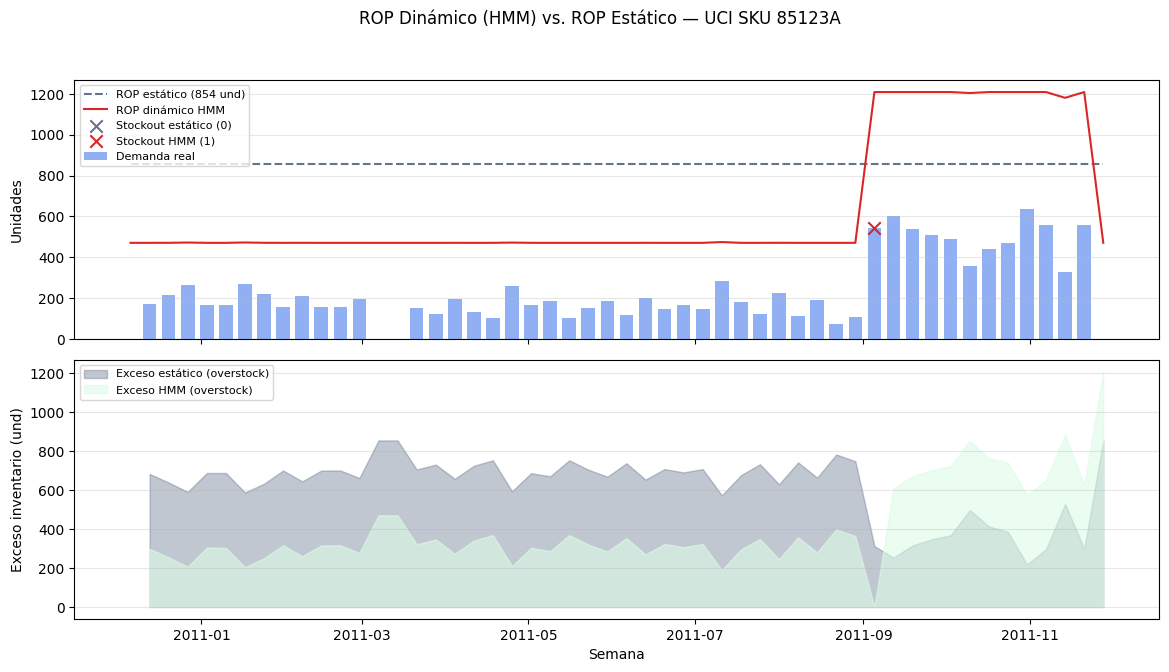

✓ data/supply_rop_comparison.png


In [10]:
# ── VISUALIZACIÓN — ROP dinámico vs. estático ────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                          gridspec_kw={'hspace': 0.08})
fig.suptitle('ROP Dinámico (HMM) vs. ROP Estático — UCI SKU 85123A', fontsize=12)

ax1 = axes[0]
ax1.bar(df.index, df.demand, color=C['demand'], alpha=0.5, width=5, label='Demanda real')
ax1.plot(df.index, df.rop_global, color=C['neutral'], lw=1.5,
         ls='--', label=f'ROP estático ({rop_global:.0f} und)')
ax1.plot(df.index, df.rop_hmm, color=C['poc'], lw=1.5,
         label='ROP dinámico HMM')
# Marcar stockouts
so_g = df[df.stockout_global]
so_h = df[df.stockout_hmm]
ax1.scatter(so_g.index, so_g.demand, marker='x', s=80, color=C['neutral'],
            zorder=5, label=f'Stockout estático ({len(so_g)})')
ax1.scatter(so_h.index, so_h.demand, marker='x', s=80, color=C['poc'],
            zorder=5, label=f'Stockout HMM ({len(so_h)})')
ax1.set_ylabel('Unidades')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.fill_between(df.index, df.excess_global, alpha=0.4, color=C['neutral'],
                 label='Exceso estático (overstock)')
ax2.fill_between(df.index, df.excess_hmm, alpha=0.6, color=C['fill1'],
                 label='Exceso HMM (overstock)')
ax2.set_ylabel('Exceso inventario (und)')
ax2.set_xlabel('Semana')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/supply_rop_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('✓ data/supply_rop_comparison.png')

In [11]:
# ── EXPORTAR ─────────────────────────────────────────────────────────────────
df.to_csv('data/supply_hmm_output.csv')
print('✓ data/supply_hmm_output.csv')
print('✓ data/supply_eda.png')
print('✓ data/supply_dashboard.png')
print('✓ data/supply_rop_comparison.png')

✓ data/supply_hmm_output.csv
✓ data/supply_eda.png
✓ data/supply_dashboard.png
✓ data/supply_rop_comparison.png


## Conclusiones

| Concepto | Finanzas (S&P 500) | Supply Chain (UCI SKU 85123A) |
|----------|--------------------|------------------------------|
| Variable observada | Retorno diario | Demanda semanal |
| Estados ocultos | Bull / Bear / Alta Vol | Normal / Navidad |
| Forward | Régimen actual del mercado | ¿Estamos en campaña esta semana? |
| Viterbi | Etiqueta histórica de cada día | Etiqueta histórica de cada semana |
| Baum-Welch | Aprende μ/σ de retornos por régimen | Aprende μ/σ de demanda por régimen |
| Aplicación | Cambiar estrategia de trading | Cambiar ROP y SS automáticamente |

**Limitación clave:** El HMM asume que la distribución de emisión es Gaussiana. Si la demanda tiene colas muy pesadas (kurtosis > 5) o muchos ceros, una distribución de Poisson o Negative Binomial puede ser más apropiada — pero requiere implementación custom del paso M del Baum-Welch.

**Conexión con el siguiente modelo:** La σ que estima el HMM para cada régimen es una σ estática dentro del régimen. Si dentro del régimen de campaña la volatilidad también tiene clusters (picos de demanda antes de Navidad seguidos de caída), se necesita **GARCH (T4)** — que modela la varianza condicional día a día dentro del régimen.